# QORC on a Lorenz Time Series

This notebook is a demonstration of how to apply a **Quantum Optical Reservoir Computing (QORC)** pipeline to a concrete time-series task.

The original implementation is from the public repository:
[`bero1403/QRC`](https://github.com/bero1403/QRC) and was performed by [Olivier Bergeron](https://github.com/bero1403) and [Louis Desruisseaux](https://github.com/Deslouis), [Université de Sherbrooke](https://www.usherbrooke.ca), in Fall 2025. Their codebase is distributed under the **MIT License**.

We start with the Lorenz dataset and perform one-step-ahead forecasting of all three coordinates (`x`, `y`, `z`).


## 1. Imports and local definitions

This notebook is self-contained: all helper classes and functions are defined inline, so no external package beyond `merlin` and its dependencies is needed.

Key dependencies:
- **NumPy / Pandas**: data loading and manipulation
- **Matplotlib**: visualization
- **PyTorch**: neural network training (MLP readout)
- **Perceval**: photonic quantum circuit description
- **Merlin**: bridges Perceval circuits into PyTorch-compatible quantum layers


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.optim import Optimizer
from torch.utils.data import Dataset, DataLoader

import perceval as pcvl
import merlin as ML

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

## 2. Load and Display Lorenz data

The Lorenz system is a canonical example of deterministic chaos:
- **Deterministic**: same initial conditions always produce the same trajectory.
- **Chaotic**: tiny perturbations amplify exponentially (sensitive dependence on initial conditions).
- **Three coupled ODEs** with three variables: x(t), y(t), z(t).

This makes it an excellent benchmark for time series prediction: it's nonlinear, chaotic, but still deterministic (in principle perfectly predictable if we had infinite precision).


**First-order Markov property:**
The Lorenz system is a first-order ODE system — the time derivative at time $t$ depends only on the current state $(x(t), y(t), z(t))$, not on any past state. When the trajectory is discretised at a fixed time step $\Delta t$, this property carries over: the next state $s_{t+1}$ depends (approximately) only on the current state $s_t$. Formally, $P(s_{t+1} \mid s_t, s_{t-1}, \ldots) \approx P(s_{t+1} \mid s_t)$. This **Markov order 1** structure justifies using a single time step as the model input — there is no need for a look-back window.

#### 2.1. Load the data

The dataset is the trajectory of the Lorenz system sampled at 1000 discrete time steps. It is loaded directly from a public benchmark repository and columns are renamed to `x`, `y`, `z` for clarity.


In [44]:
# Load the Lorenz dataset from the benchmark repository
# The Lorenz system is a classic chaotic dynamical system with three variables (x, y, z)
LZ_URL = "https://raw.githubusercontent.com/tobias-fllnr/VariationalQMLTimeSeriesBenchmark/main/TimeseriesData/lorenz_1000.csv"
lorenz_df = pd.read_csv(LZ_URL)

# Standardize column names for consistency throughout the notebook
# Rename coordinates columns to simple names
column_mapping = {}
for col in lorenz_df.columns:
    if 'x' in col.lower():
        column_mapping[col] = 'x'
    elif 'y' in col.lower():
        column_mapping[col] = 'y'
    elif 'z' in col.lower():
        column_mapping[col] = 'z'
lorenz_df.rename(columns=column_mapping, inplace=True)

print(lorenz_df.head())
print("\nShape:", lorenz_df.shape)
print("Columns:", list(lorenz_df.columns))


          x         y          z
0 -0.743562 -1.998498  19.774099
1 -1.091362 -2.185388  18.309356
2 -1.415734 -2.506093  16.986388
3 -1.759038 -2.977298  15.805615
4 -2.158417 -3.625404  14.776550

Shape: (1000, 3)
Columns: ['x', 'y', 'z']


#### 2.2. Visualize the data

Two complementary views help build intuition about the dataset:
- **Time-series plot**: shows each coordinate independently over time. Notice the irregular oscillations — a hallmark of chaotic dynamics.
- **3D phase-space plot**: shows the famous butterfly-shaped Lorenz attractor. The trajectory never exactly repeats, yet stays bounded, illustrating how chaos and structure coexist.


Lorenz data shape: (1000, 3)


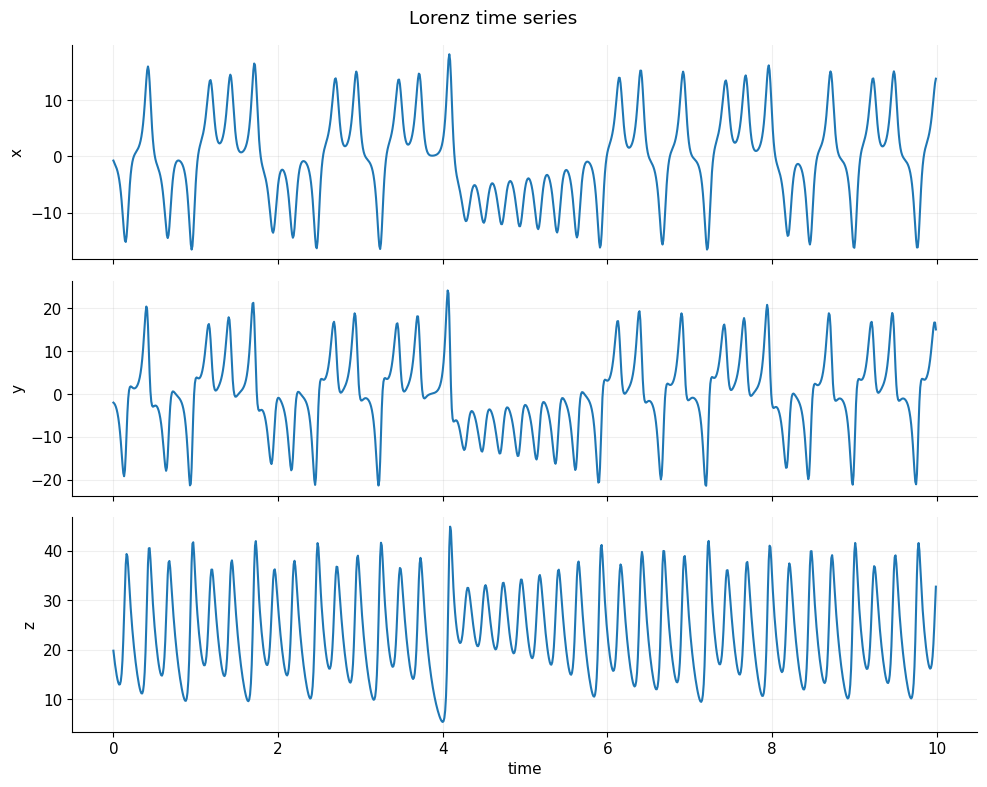

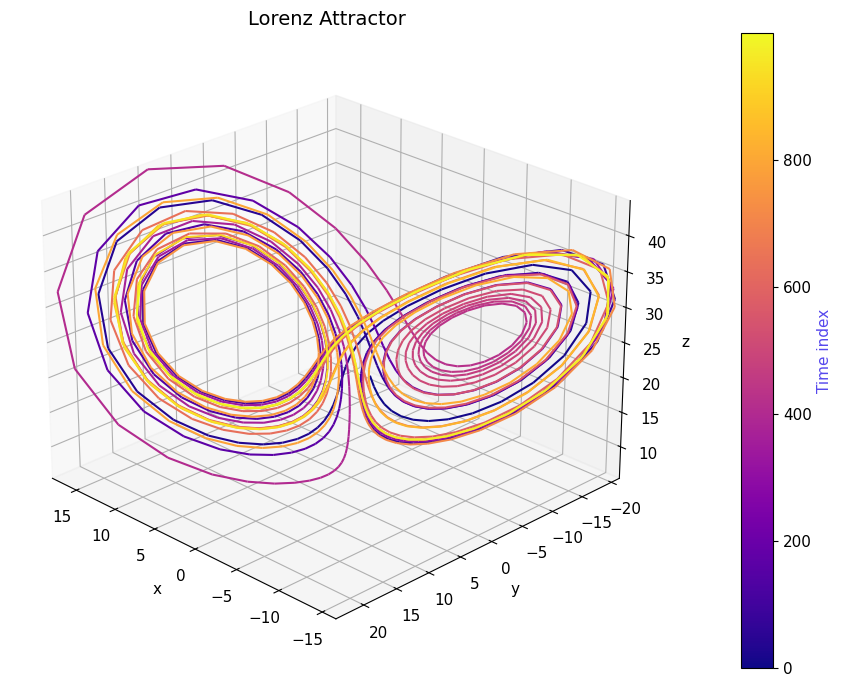

In [59]:
from matplotlib.collections import LineCollection

PRIMARY_COLOR = "#5648ED"

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.2,
    "font.size": 11
})

# Visualize the three coordinates of the Lorenz system
# The Lorenz system exhibits chaotic behavior: small differences in initial conditions
# lead to dramatically different trajectories
def plot_time_series(data, dt=0.01, n_plot=1000): 
    """ Plot x(t), y(t), z(t) over time 
    (first n_plot points). data: (T, 3) """ 
    T = data.shape[0] 
    n_plot = min(n_plot, T) 
    t = np.arange(n_plot) * dt 
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True) 
    labels = ['x', 'y', 'z'] 
    for i, ax in enumerate(axes): 
        ax.plot(t, data[:n_plot, i]) 
        ax.set_ylabel(labels[i]) 
    axes[-1].set_xlabel('time') 
    fig.suptitle('Lorenz time series') 
    plt.tight_layout() 
    plt.show()

from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.cm import ScalarMappable

PRIMARY_COLOR = "#5648ED"

def plot_lorenz_3d(data, n_plot=2000):
    n_plot = min(n_plot, data.shape[0])
    xs, ys, zs = data[:n_plot].T

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Build line segments
    points = np.array([xs, ys, zs]).T.reshape(-1, 1, 3)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # Time index (what drives color)
    t = np.arange(n_plot)

    # Colormap normalization
    norm = plt.Normalize(t.min(), t.max())

    lc = Line3DCollection(
        segments,
        cmap="plasma",
        norm=norm
    )
    lc.set_array(t)
    lc.set_linewidth(1.5)

    ax.add_collection(lc)

    # Axis limits
    ax.set_xlim(xs.min(), xs.max())
    ax.set_ylim(ys.min(), ys.max())
    ax.set_zlim(zs.min(), zs.max())

    ax.set_title("Lorenz Attractor", fontsize=14)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    # Viewing angle
    ax.view_init(elev=25, azim=135)

    # ---- Colorbar (this is your "heatmap legend") ----
    sm = ScalarMappable(cmap="plasma", norm=norm)
    sm.set_array([])  # required for matplotlib < 3.7 compatibility

    cbar = fig.colorbar(sm, ax=ax, pad=0.1)
    cbar.set_label("Time index", color=PRIMARY_COLOR)

    plt.tight_layout()
    plt.show()

# Extract data as numpy array
data = lorenz_df[["x", "y", "z"]].values.astype(np.float64)
print("Lorenz data shape:", data.shape)  # (N, 3)

# Choose a dt (only used for plotting)
dt = 0.01

# Visualization
plot_time_series(data, dt=dt, n_plot=1000)
plot_lorenz_3d(data, n_plot=1000)

#### 2.3. Data handling for PyTorch processing

Two helper `Dataset` classes are defined here:

- **`TensorDataset`**: a lightweight wrapper that bundles one or two input arrays with a target array. It supports the optional second input needed later to pass both classical and quantum features to the model.
- **`TimeSeriesDataset`**: converts a continuous time series into sliding windows of a fixed size. It generalises the one-step-ahead setting to arbitrary look-back (`input_width`) and look-ahead (`target_width`) horizons. *This class is defined for future extensibility but is not used in the main pipeline below.*

A **`normalize_standard_scaler`** helper applies z-score normalization:
$$\hat{x} = \frac{x - \mu}{\sigma + \epsilon}$$
where $\epsilon = 10^{-8}$ prevents division by zero.


In [46]:
class TensorDataset(Dataset):
    """
    A simple PyTorch Dataset wrapper for tensor input-target pairs.
    
    Converts numpy arrays or lists to PyTorch tensors and provides standard
    Dataset interface for use with DataLoader.
    
    Can optionally take a second input array (e.g., for quantum features).
    """
    def __init__(self, inputs, targets, inputs2=None):
        if isinstance(inputs, torch.Tensor):
            self.inputs = inputs.detach().clone()
        else:
            self.inputs = torch.tensor(inputs)

        if isinstance(targets, torch.Tensor):
            self.targets = targets.detach().clone()
        else:
            self.targets = torch.tensor(targets)
        
        # Optional second input (e.g., quantum features)
        self.inputs2 = None
        if inputs2 is not None:
            if isinstance(inputs2, torch.Tensor):
                self.inputs2 = inputs2.detach().clone()
            else:
                self.inputs2 = torch.tensor(inputs2)

        self.n_items = self.inputs.shape[0]
        assert self.n_items == self.targets.shape[0], (
            f"TensorDataset: inputs and targets do not have the same number of rows. "
            f"self.inputs.shape: {self.inputs.shape}, self.targets.shape: {self.targets.shape}"
        )
        
        if self.inputs2 is not None:
            assert self.n_items == self.inputs2.shape[0], (
                f"TensorDataset: inputs and inputs2 do not have the same number of rows. "
                f"self.inputs.shape: {self.inputs.shape}, self.inputs2.shape: {self.inputs2.shape}"
            )

    def __getitem__(self, index):
        if self.inputs2 is not None:
            return self.inputs[index], self.inputs2[index], self.targets[index]
        else:
            return self.inputs[index], self.targets[index]

    def __len__(self):
        return self.n_items


class TimeSeriesDataset(Dataset):
    """
    Converts a continuous time series into supervised learning windows.
    
    Given a time series, this class creates a set of sliding windows where:
    - input_width: number of past timesteps used as features
    - target_width: number of future timesteps used as targets
    - shift: gap between input and target (for multi-step ahead prediction)
    
    Example: input_width=8, target_width=1 creates 8-step lookback, 1-step lookahead.
    """
    def __init__(
        self,
        data: pd.DataFrame,
        input_width: int,
        target_width: int,
        shift: int = 0,
        target_columns=None,
        dtype=None,
    ):
        self.dtype = dtype if dtype else torch.get_default_dtype()
        self.data = data

        # If specified, only extract these columns as targets (useful for multi-output forecasting)
        self.target_columns = target_columns
        if target_columns is not None:
            self.target_columns = {name: i for i, name in enumerate(target_columns)}

        # Create a mapping from column names to indices
        self.columns_indices = {name: i for i, name in enumerate(data.columns)}
        self.n_features = len(self.columns_indices)

        self.input_width = input_width
        self.target_width = target_width
        self.shift = shift

        # Total window size includes inputs, gap (shift), and targets
        self.total_window_size = input_width + target_width + shift

        # Indices for extracting input and target from each window
        self.input_slice = slice(0, input_width)
        self.input_indices = np.arange(self.total_window_size)[self.input_slice]

        self.target_start = self.total_window_size - self.target_width
        self.targets_slice = slice(self.target_start, None)
        self.target_indices = np.arange(self.total_window_size)[self.targets_slice]

        # Calculate how many windows we can create from the data
        num_timesteps = data.shape[0]
        self.num_sequences = num_timesteps - self.total_window_size + 1

        # Pre-compute all sliding windows and split into inputs/targets
        sliding_window_tensor = self.create_sliding_windows(data)
        self.inputs, self.targets = self.split_window(sliding_window_tensor)

    def __repr__(self):
        return "\n".join([
            f"Total window size: {self.total_window_size}",
            f"Input indices: {self.input_indices}",
            f"target indices: {self.target_indices}",
            f"target column name(s): {self.target_columns}",
        ])

    def split_window(self, features: torch.Tensor):
        """Extract input and target portions from concatenated windows."""
        inputs = features[:, self.input_slice, :]
        targets = features[:, self.targets_slice, :]

        # If target_columns specified, select only those columns
        if self.target_columns is not None:
            targets = torch.stack(
                [targets[:, :, self.columns_indices[name]] for name in self.target_columns],
                dim=-1,
            )

        return inputs, targets

    def create_sliding_windows(self, data: pd.DataFrame):
        """Create all sliding windows by shifting a window of size total_window_size."""
        data_tensor = torch.tensor(data.to_numpy(), dtype=self.dtype)
        windows = []
        for i in range(self.num_sequences):
            windows.append(data_tensor[i : self.total_window_size + i, :])
        return torch.stack(windows, dim=0)

    def __getitem__(self, index):
        return self.inputs[index, :, :], self.targets[index, :, :]

    def __len__(self):
        return self.num_sequences
    

def normalize_standard_scaler(data, mean, std):
    """
    Normalize data using standard scaling (z-score normalization).
    Formula: (x - mean) / std
    
    Note: epsilon added to std to avoid division by zero.
    """
    epsilon = 1e-8
    return (data - mean) / (std + epsilon)



## 3. Definition of the Quantum Optical Reservoir

A **quantum optical reservoir** is a fixed (non-trainable) photonic circuit that acts as a nonlinear feature extractor. Its role is analogous to the hidden layer of a classical reservoir computer: it projects the low-dimensional input into a richer feature space, where a simple linear readout can solve the prediction task.

The reservoir consists of:
1. **Random unitary interferometers** — fixed, randomly drawn beam-splitter networks that mix the optical modes.
2. **Input-encoding phase shifters** — phase shifts whose values are set by the input data at inference time.
3. **Photon-counting measurement** — the output is the probability distribution over photon-number patterns across all modes.

Because the weights of the interferometers are *never updated*, the expensive quantum simulation is run only once (feature extraction), after which only the lightweight classical readout is trained.

The quantum features extracted from the fixed reservoir (A) are concatenaded to the classical inputs and fed to the trainable 2-layer MLP (2).
![Quantum Optical Reservoir for time series forecasting](../_static/img/QORC-time.png)


#### 3.1. Circuit definition

The `quantum_reservoir` function assembles the Perceval circuit and wraps it in a Merlin `QuantumLayer`. The circuit layout is:

```
random_unitary → [phase_encoding → random_unitary] × n_layer
```

- `n_modes`: number of optical modes, equal to the input dimension (3 for the Lorenz `x`, `y`, `z` coordinates).
- `n_photons`: number of photons injected; more photons yield richer output statistics (larger output dimension) at higher simulation cost.
- `n_layer`: number of encode–mix repetitions. A single layer is sufficient for this task.
- `n_params_per_layer`: how many input values are encoded via phase shifts per layer (up to `n_modes`).

The same phase-shift names (`px1`, `px2`, ...) are reused across layers, so the same input values are re-injected at each encoding step — a simple form of input re-use that deepens the circuit without requiring extra input features.


In [47]:
def quantum_reservoir(n_photons: int, n_modes: int, **options) -> ML.QuantumLayer:
    """
    Build a Quantum Optical Reservoir (QOR) circuit.

    Reservoir computing uses a fixed, random nonlinear dynamical system
    to transform input features into a high-dimensional feature space.
    Here, we use quantum photonics as that nonlinear system:

    Circuit structure:
    1. Initial random interferometer (fixed unitary mixing)
    2. For each layer:
       - Input encoding (phase shifts determined by input features)
       - Another random interferometer
    3. Photon counting measurement to extract features

    Args:
        n_photons: number of photons in the quantum state (quantum resources)
        n_modes: number of optical modes (channels)
        n_layer: number of encoding/interferometer blocks (default: 1)
        n_params_per_layer: number of encoded parameters per layer (default: n_modes)

    Returns:
        Merlin QuantumLayer that can be used like a PyTorch module
    """
    n_layer = options.get("n_layer", 1)
    if n_layer <= 0:
        raise ValueError("n_layer must be a positive integer")

    n_params_per_layer = options.get("n_params_per_layer", n_modes)
    if not (1 <= n_params_per_layer <= n_modes):
        raise ValueError("n_params_per_layer must be in [1, n_modes]")

    # Shared input encoding block. Reusing parameter names (px1..pxk)
    # applies the same input-dependent phase encoding at each layer.
    c_var = pcvl.Circuit(n_modes)
    for i in range(n_params_per_layer):
        px = pcvl.P(f"px{i + 1}")
        c_var.add(i, pcvl.PS(px))

    haar_circuit = pcvl.Unitary(pcvl.Matrix.random_unitary(n_modes))
    for _ in range(n_layer):
        circuit = haar_circuit // c_var // haar_circuit

    return ML.QuantumLayer(
        input_size=n_modes,
        circuit=circuit,
        n_photons=n_photons,
        input_parameters=["px"],
    )


#### 3.2. Feature extraction utility

Simulating a quantum circuit is memory-intensive: the full probability distribution over all photon-number basis states must be computed for each sample. To avoid out-of-memory errors on large datasets, `batch_compute_quantum_layer` splits the data into chunks of `batch_size` samples and concatenates the results.

This wrapper is used in Section 6 when running the reservoir forward pass on the training, validation and test sets.


In [48]:
def batch_compute_quantum_layer(
    quantum_layer: ML.QuantumLayer,
    data: torch.Tensor,
    batch_size: int = 1000,
) -> torch.Tensor:
    """
    Process data through quantum layer in batches.
    
    Quantum simulations are memory-intensive. This function processes data
    in smaller batches to avoid memory overflow while maintaining correctness.
    
    Args:
        quantum_layer: the QuantumLayer to apply
        data: input tensor of shape (N, n_features)
        batch_size: number of samples per batch
    
    Returns:
        Output tensor of shape (N, output_dim)
    """
    sample_size = data.shape[0]
    n_batches = (sample_size + batch_size - 1) // batch_size

    outputs = []
    for i in range(n_batches):
        start = i * batch_size
        end = min(start + batch_size, sample_size)
        with torch.no_grad():
            outputs.append(quantum_layer(data[start:end]))

    return torch.cat(outputs, dim=0)


## 4. Train/validation/test split + normalization

**Why split the data?**
- **Training set (70%)**: Learn model parameters
- **Validation set (15%)**: Monitor overfitting during training, tune hyperparameters
- **Test set (15%)**: Final unbiased evaluation (never touch this until the end!)

**Why normalize?**
- Neural networks train faster on normalized inputs (roughly unit variance, zero mean)
- Prevents large-scale features from dominating
- Standard scaling (z-score): subtract mean, divide by std

**Critical rule**: Compute mean/std ONLY from training data, then apply to all splits (including val/test). This prevents information leakage.


In [49]:
# Split data into train/val/test sets
# Train: 70% - used to fit parameters
# Val: 15% - used to monitor overfitting during training
# Test: 15% - held out to evaluate final performance
n = len(lorenz_df)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

train_df = lorenz_df.iloc[:train_end].copy()
val_df = lorenz_df.iloc[train_end:val_end].copy()
test_df = lorenz_df.iloc[val_end:].copy()

# Compute normalization statistics from TRAINING data only
# (Important: never use validation/test data for computing statistics to avoid data leakage)
train_mean = train_df.mean()
train_std = train_df.std()

# Apply the same normalization (z-score) to all splits using training statistics
train_norm = normalize_standard_scaler(train_df, train_mean, train_std)
val_norm = normalize_standard_scaler(val_df, train_mean, train_std)
test_norm = normalize_standard_scaler(test_df, train_mean, train_std)

print(f"Train/Val/Test sizes: {len(train_norm)} / {len(val_norm)} / {len(test_norm)}")


Train/Val/Test sizes: 700 / 150 / 150


## 5. Build one-step prediction datasets

**One-step ahead forecasting:**
For each timestep, we predict the next timestep:
```
Raw series: [a, b, c, d, e, f, g, ...]
Pair 1:   a → b
Pair 2:   b → c
Pair 3:   c → d
...
```

This creates N−1 training examples from N timesteps.

**Dataset structure:**
- Input: current state `(x, y, z)` at time $t$
- Output: next state `(x, y, z)` at time $t+1$
- We predict all 3 coordinates jointly


**Why a single time step is sufficient:**
As noted in Section 2, the Lorenz system is first-order Markov: $s_{t+1}$ depends only on $s_t$. There is therefore no information gain from including older time steps $s_{t-2}, s_{t-3}, \ldots$ as additional inputs. Using a look-back window of exactly 1 is both theoretically justified and practically the simplest choice.

In [50]:
# Create one-step prediction datasets
# Simple approach: X[t] → y[t+1]

def create_one_step_dataset(data):
    """
    Create one-step ahead prediction pairs.
    Args:
        data: numpy array of shape (T, 3) or DataFrame
    Returns:
        X: array of shape (T-1, 3) - current state
        y: array of shape (T-1, 3) - next state
    """
    if isinstance(data, pd.DataFrame):
        data = data.values
    X = data[:-1]  # All timesteps except last
    y = data[1:]   # All timesteps except first (shifted by 1)
    return X, y

# Convert DataFrames to numpy for easier manipulation
train_data = train_norm.values
val_data = val_norm.values
test_data = test_norm.values

# Create one-step pairs
X_train, y_train = create_one_step_dataset(train_data)
X_val, y_val = create_one_step_dataset(val_data)
X_test, y_test = create_one_step_dataset(test_data)

print(f"Train set: X shape {X_train.shape}, y shape {y_train.shape}")
print(f"Val set:   X shape {X_val.shape}, y shape {y_val.shape}")
print(f"Test set:  X shape {X_test.shape}, y shape {y_test.shape}")


Train set: X shape (699, 3), y shape (699, 3)
Val set:   X shape (149, 3), y shape (149, 3)
Test set:  X shape (149, 3), y shape (149, 3)


## 6. Build QORC reservoir and extract features

**Reservoir Computing Concept:**
Instead of training a deep neural network end-to-end (hard to optimise, prone to overfitting), reservoir computing uses a *fixed, random, nonlinear* dynamical system to project inputs into a high-dimensional feature space. A simple linear readout is then trained on those features.

Here, the reservoir is a **quantum optical circuit**: a linear photonic network whose nonlinearity arises from the indistinguishability of photons and the combinatorial statistics of multi-photon detection.

**Pipeline (used in this notebook):**
1. Each normalised state `(x, y, z)` is encoded into the circuit via phase shifts.
2. The circuit evolves the state; photon-count probabilities across all modes form the output feature vector.
3. The quantum features are concatenated with the original input (`x, y, z`).
4. A classical MLP readout (the only trainable part) maps this concatenated vector to the next-step prediction.

**Why fix the reservoir?**
- A fixed circuit means the quantum simulation is run only once per dataset, not once per training iteration.
- This makes training fast and avoids the gradient instability issues that affect end-to-end quantum–classical optimisation.

**Note on the source of nonlinearity:**
Linear optics is unitary on the field amplitudes. Nonlinearity enters through *multi-photon interference* (the Hong-Ou-Mandel effect and its generalisations) combined with photon-counting measurement: the output probabilities are high-degree polynomials in the circuit parameters and input phases.


In [ ]:
# Create the Quantum Optical Reservoir (QOR)
# A reservoir is a fixed, nonlinear feature extractor (not trained).
# The quantum circuit transforms input features into a high-dimensional quantum state.

n_modes = 3  # Number of input features (x, y, z)
n_photons = 3  # Number of photons

reservoir = quantum_reservoir(
    n_photons=n_photons,
    n_modes=n_modes,
    n_layer=1,
)
reservoir.eval()  # Freeze the quantum layer

print(f"Reservoir: n_modes={n_modes}, n_photons={n_photons}")
print(f"Reservoir output size: {reservoir.output_size}")


Reservoir: n_modes=3, n_photons=3
Reservoir output size: 1


In [52]:
# Extract quantum reservoir features for the input data
def extract_reservoir_features(X, qlayer, batch_size=256):
    """
    Apply quantum reservoir to input data.
    
    Args:
        X: input array of shape (N, 3)
        qlayer: quantum layer
        batch_size: batch size for processing
    
    Returns:
        Quantum features of shape (N, output_size)
    """
    X_tensor = torch.tensor(X, dtype=torch.float32)
    q_features = batch_compute_quantum_layer(qlayer, X_tensor, batch_size=batch_size)
    return q_features.detach().cpu().numpy()

print("Extracting quantum features...")
X_train_q = extract_reservoir_features(X_train, reservoir)
X_val_q = extract_reservoir_features(X_val, reservoir)
X_test_q = extract_reservoir_features(X_test, reservoir)

print(f"Quantum features shape:")
print(f"  Train: {X_train_q.shape}")
print(f"  Val:   {X_val_q.shape}")
print(f"  Test:  {X_test_q.shape}")


Extracting quantum features...
Quantum features shape:
  Train: (699, 1)
  Val:   (149, 1)
  Test:  (149, 1)


## 7. Train MLP readout (classical head)

The `QuantumOpticalReservoir` module implements the full QORC model. Its `forward` method concatenates the (pre-computed, fixed) quantum features with the original input, then passes the result through a small MLP:

```
input: [quantum_features | original_input]  →  Linear(hidden)  →  ReLU  →  Linear(3)  →  (x̂, ŷ, ẑ)
```

The quantum reservoir is **not** part of the computational graph here: quantum features were extracted once in Section 6 and stored as tensors. Only the MLP weights are updated by gradient descent.

**Training setup:**
| Hyperparameter | Value |
|---|---|
| Optimizer | Adam |
| Learning rate | 1 × 10⁻³ |
| Loss | MSE |
| Epochs | 200 |
| Batch size | 32 |
| Hidden units | 64 |

**Validation mode — teacher forcing:**
At each epoch, validation loss is computed by passing the entire validation set through the model **in a single forward pass**, where every input is the *true* ground-truth state $s_t$ (not a previously predicted state). This is called **teacher forcing**: errors do not accumulate across time steps during validation, so the reported loss is a clean measure of per-step prediction quality. Because the model is small and the reservoir is fixed, overfitting is unlikely, but monitoring the validation curve remains a useful sanity check.


In [53]:
class QuantumOpticalReservoir(nn.Module):
    """
    QORC: Quantum Optical Reservoir Computing + MLP readout.
    
    Architecture:
    1. Quantum reservoir transforms input → quantum features
    2. Concatenate quantum features with original input
    3. MLP readout: Linear → ReLU → Linear
    """
    def __init__(self, input_dim=3, quantum_feat_dim=None, hidden_dim=64, output_dim=3):
        super().__init__()
        if quantum_feat_dim is None:
            quantum_feat_dim = input_dim
        
        total_input = input_dim + quantum_feat_dim
        self.net = nn.Sequential(
            nn.Linear(total_input, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x_orig, x_quantum):
        # Concatenate original input and quantum features
        x = torch.cat([x_quantum, x_orig], dim=1)
        return self.net(x)

# Create model
model = QuantumOpticalReservoir(
    input_dim=3,
    quantum_feat_dim=X_train_q.shape[1],
    hidden_dim=64,
    output_dim=3
)

# Set up optimizer and loss
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # Adam optimizer

# Convert data to tensors
X_train_orig_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_orig_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
X_test_orig_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

X_train_q_t = torch.tensor(X_train_q, dtype=torch.float32)
X_val_q_t = torch.tensor(X_val_q, dtype=torch.float32)
X_test_q_t = torch.tensor(X_test_q, dtype=torch.float32)

# Training loop
train_losses = []
val_losses = []
n_epochs = 200
batch_size = 32

train_dataset = TensorDataset(X_train_orig_t, y_train_t, X_train_q_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

for epoch in range(1, n_epochs + 1):
    model.train()
    epoch_loss = 0.0
    
    for x_orig, x_q, y in train_loader:
        optimizer.zero_grad()
        pred = model(x_orig, x_q)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    train_losses.append(epoch_loss / len(train_loader))
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_orig_t, X_val_q_t)
        val_loss = criterion(val_pred, y_val_t).item()
    
    val_losses.append(val_loss)
    
    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | Train loss: {train_losses[-1]:.6f} | Val loss: {val_loss:.6f}")

print(f"\nTraining complete! Final train loss: {train_losses[-1]:.6f}, Final val loss: {val_losses[-1]:.6f}")
    

Epoch   1 | Train loss: 0.823368 | Val loss: 0.647835
Epoch  20 | Train loss: 0.003707 | Val loss: 0.003251
Epoch  40 | Train loss: 0.001365 | Val loss: 0.001141
Epoch  60 | Train loss: 0.000728 | Val loss: 0.000648
Epoch  80 | Train loss: 0.000447 | Val loss: 0.000424
Epoch 100 | Train loss: 0.000303 | Val loss: 0.000281
Epoch 120 | Train loss: 0.000228 | Val loss: 0.000197
Epoch 140 | Train loss: 0.000176 | Val loss: 0.000164
Epoch 160 | Train loss: 0.000142 | Val loss: 0.000147
Epoch 180 | Train loss: 0.000117 | Val loss: 0.000111
Epoch 200 | Train loss: 0.000093 | Val loss: 0.000096

Training complete! Final train loss: 0.000093, Final val loss: 0.000096


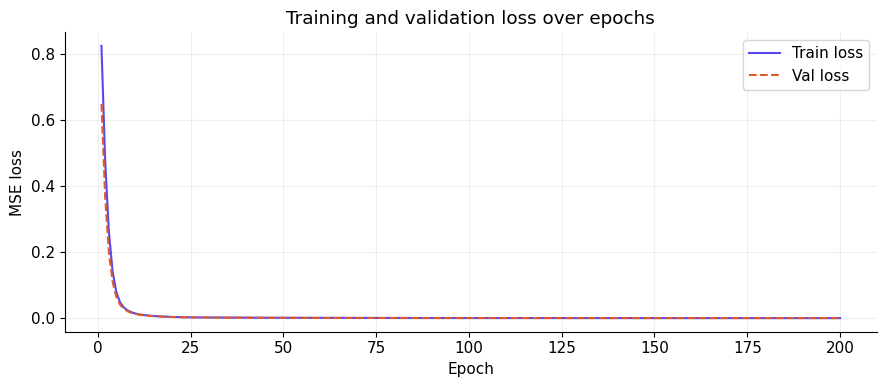

In [54]:
epochs = range(1, n_epochs + 1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs, train_losses, label="Train loss", color="#5648ED")
ax.plot(epochs, val_losses,   label="Val loss",   color="#E05A2B", linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Training and validation loss over epochs")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Evaluate and visualise results

Evaluation is performed on all three splits (train / validation / test):
1. Run the trained MLP on the pre-extracted quantum features.
2. **Denormalise** predictions and ground truth back to the original Lorenz scale (multiply by `train_std`, add `train_mean`).
3. Report per-coordinate **MSE** and **MAE**:

$$\text{MSE} = \frac{1}{N}\sum_{t=1}^{N}(\hat{y}_t - y_t)^2, \qquad \text{MAE} = \frac{1}{N}\sum_{t=1}^{N}|\hat{y}_t - y_t|$$

4. Plot predicted vs. true trajectories for all three coordinates. Vertical dotted lines mark the train/validation and validation/test boundaries.

**Important — teacher-forced evaluation:**
All splits are evaluated with **teacher forcing**: each prediction $\hat{s}_{t+1}$ is made from the *true* state $s_t$, not from the previously predicted $\hat{s}_t$. Concretely, the entire test set is scored in **one forward pass** — there is no recurrent loop feeding predictions back as inputs.



This means the metrics reflect per-step prediction accuracy in isolation. They will generally be more optimistic than **autoregressive (rollout) evaluation**, where the model feeds its own output back as input and errors compound over time. Rollout evaluation is a natural next experiment (see "Next directions").The test split was never used during training or hyperparameter selection, so its teacher-forced metrics give an honest estimate of single-step generalisation performance.

See Section 9 for an autoregressive rollout evaluation.


In [55]:
# Generate predictions on all splits
model.eval()
with torch.no_grad():
    train_pred_norm = model(X_train_orig_t, X_train_q_t).cpu().numpy()
    val_pred_norm = model(X_val_orig_t, X_val_q_t).cpu().numpy()
    test_pred_norm = model(X_test_orig_t, X_test_q_t).cpu().numpy()

# Extract ground truth (already normalized)
train_true_norm = y_train_t.cpu().numpy()
val_true_norm = y_val_t.cpu().numpy()
test_true_norm = y_test_t.cpu().numpy()

# Denormalize back to original scale
# Get denormalization stats for all 3 coordinates
mean_y = train_mean.values  # (3,) array for [x, y, z]
std_y = train_std.values    # (3,) array for [x, y, z]

def denorm_all(v_norm):
    """Denormalize from normalized to original scale."""
    return v_norm * std_y + mean_y

train_pred = denorm_all(train_pred_norm)
val_pred = denorm_all(val_pred_norm)
test_pred = denorm_all(test_pred_norm)

train_true = denorm_all(train_true_norm)
val_true = denorm_all(val_true_norm)
test_true = denorm_all(test_true_norm)

# Compute metrics for all 3 coordinates
coords = ['x', 'y', 'z']
for i, coord in enumerate(coords):
    train_mse = np.mean((train_pred[:, i] - train_true[:, i]) ** 2)
    val_mse = np.mean((val_pred[:, i] - val_true[:, i]) ** 2)
    test_mse = np.mean((test_pred[:, i] - test_true[:, i]) ** 2)
    
    train_mae = np.mean(np.abs(train_pred[:, i] - train_true[:, i]))
    val_mae = np.mean(np.abs(val_pred[:, i] - val_true[:, i]))
    test_mae = np.mean(np.abs(test_pred[:, i] - test_true[:, i]))
    
    print(f"\n{coord.upper()} coordinate:")
    print(f"  Train MSE/MAE: {train_mse:.6f} / {train_mae:.6f}")
    print(f"  Val   MSE/MAE: {val_mse:.6f} / {val_mae:.6f}")
    print(f"  Test  MSE/MAE: {test_mse:.6f} / {test_mae:.6f}")



X coordinate:
  Train MSE/MAE: 0.002575 / 0.038677
  Val   MSE/MAE: 0.002805 / 0.040300
  Test  MSE/MAE: 0.003040 / 0.039670

Y coordinate:
  Train MSE/MAE: 0.009237 / 0.076202
  Val   MSE/MAE: 0.010551 / 0.083130
  Test  MSE/MAE: 0.008920 / 0.076592

Z coordinate:
  Train MSE/MAE: 0.009528 / 0.074733
  Val   MSE/MAE: 0.008605 / 0.074488
  Test  MSE/MAE: 0.007379 / 0.068354


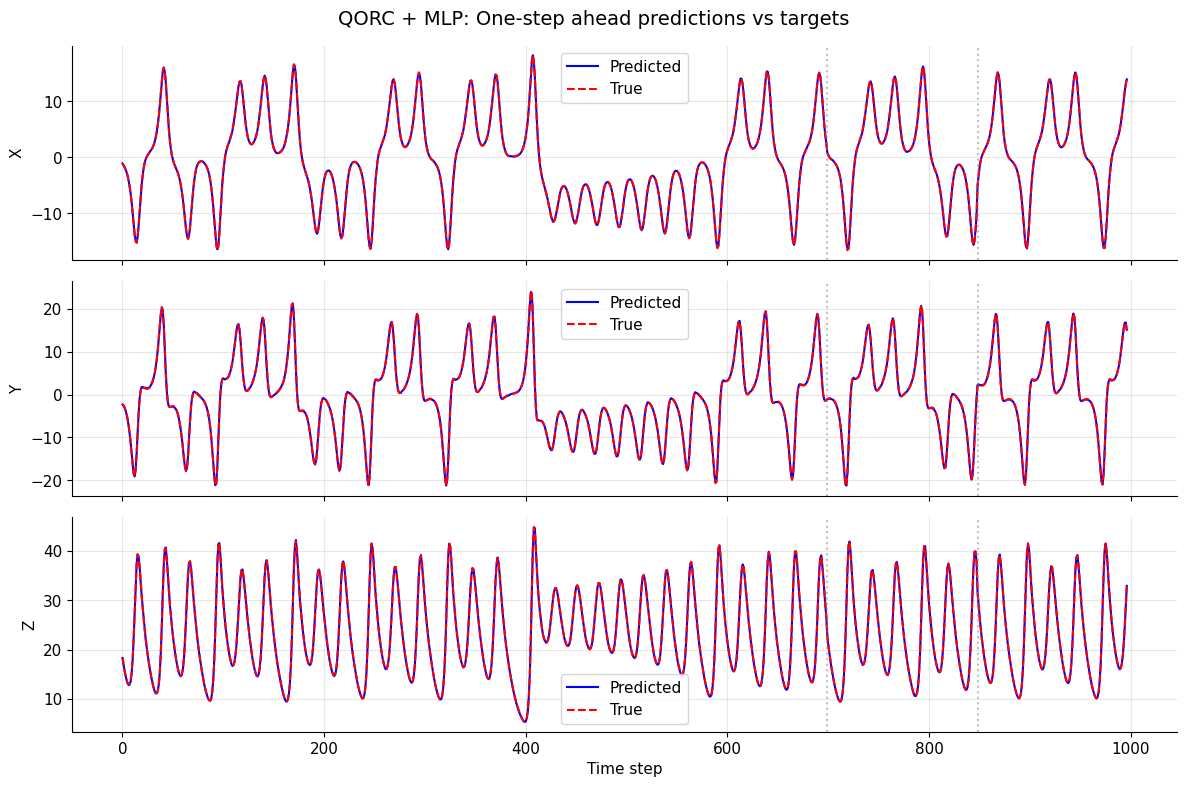

In [56]:
# Visualize predictions vs targets for one-step ahead forecasting
all_pred = np.concatenate([train_pred, val_pred, test_pred], axis=0)
all_true = np.concatenate([train_true, val_true, test_true], axis=0)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for i, coord in enumerate(['x', 'y', 'z']):
    ax = axes[i]
    ax.plot(all_pred[:, i], label='Predicted', color='blue')
    ax.plot(all_true[:, i], label='True', color='red', linestyle='--')
    ax.set_ylabel(coord.upper())
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Mark split boundaries
    train_end = len(train_pred)
    val_end = train_end + len(val_pred)
    ax.axvline(train_end, color='gray', linestyle=':', alpha=0.5)
    ax.axvline(val_end, color='gray', linestyle=':', alpha=0.5)

axes[-1].set_xlabel('Time step')
fig.suptitle('QORC + MLP: One-step ahead predictions vs targets', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Autoregressive rollout evaluation

**Motivation:**
Section 8 used **teacher forcing**: every prediction $\hat{s}_{t+1}$ was made from the *true* state $s_t$. This is the easiest setting — errors at step $t$ have no effect on step $t+1$.

In a real deployment scenario there is no oracle providing the true state: the model must feed its own prediction back as the next input. This is **autoregressive rollout**:

$$
\hat{s}_1 = f(s_0), \quad \hat{s}_2 = f(\hat{s}_1), \quad \hat{s}_3 = f(\hat{s}_2), \quad \ldots
$$

Because the Lorenz system is chaotic, small per-step errors grow exponentially. Rollout MSE will therefore be much larger than the teacher-forced MSE, and the predicted trajectory will eventually decorrelate from the true one. This is expected and physically meaningful — it reflects the *Lyapunov time* of the attractor.

**Implementation:**
- Start from the first normalised test state $s_0 = X_\text{test}[0]$.
- At each step, compute fresh quantum reservoir features for the current (predicted) state, then call the MLP readout.
- Collect the predicted trajectory and compare it against the true test trajectory.

> Note: quantum features are recomputed at every autoregressive step (one call to the reservoir per step), which is more expensive than the single batch extraction in Section 6.


In [57]:
def autoregressive_rollout(model, reservoir, s0_norm, n_steps):
    """
    Run autoregressive rollout from a single starting state.

    At each step the model's own prediction is fed back as the next input.
    Quantum reservoir features are recomputed on-the-fly for the current
    (predicted) state, so the full QORC pipeline is applied at every step.

    Args:
        model:      trained QuantumOpticalReservoir (MLP readout)
        reservoir:  fixed quantum QuantumLayer
        s0_norm:    initial normalised state, array of shape (3,)
        n_steps:    number of autoregressive steps to unroll

    Returns:
        rollout_norm: predicted normalised trajectory, shape (n_steps, 3)
    """
    model.eval()
    reservoir.eval()

    current = torch.tensor(s0_norm, dtype=torch.float32).unsqueeze(0)  # (1, 3)
    rollout = []

    with torch.no_grad():
        for _ in range(n_steps):
            # Recompute quantum features for the current (predicted) state
            q_feat = reservoir(current)          # (1, output_size)
            # Predict next state
            next_state = model(current, q_feat)  # (1, 3)
            rollout.append(next_state.squeeze(0).cpu().numpy())
            current = next_state                 # feed prediction back as input

    return np.array(rollout)  # (n_steps, 3)


# --- Run rollout from the first normalised test state ---
# X_test[0] is the first input of the test split (normalised s_0).
# We unroll for len(X_test) steps so the trajectory length matches the test set.
s0 = X_test[0]          # normalised starting point
n_rollout = len(X_test)

rollout_norm = autoregressive_rollout(model, reservoir, s0, n_rollout)

# Denormalise back to original Lorenz scale
rollout_pred = rollout_norm * std_y + mean_y
# Ground truth: the true next states starting from s0
rollout_true = test_true[: n_rollout]  # already denormalised (from Section 8)

# --- Metrics ---
coords = ['x', 'y', 'z']
print("Autoregressive rollout metrics (test set):")
for i, coord in enumerate(coords):
    mse = np.mean((rollout_pred[:, i] - rollout_true[:, i]) ** 2)
    mae = np.mean(np.abs(rollout_pred[:, i] - rollout_true[:, i]))
    print(f"  {coord.upper()}:  MSE = {mse:.4f}  |  MAE = {mae:.4f}")

print("\nTeacher-forced metrics (from Section 8) are shown above for comparison.")


Autoregressive rollout metrics (test set):
  X:  MSE = 45.2185  |  MAE = 4.2953
  Y:  MSE = 79.0426  |  MAE = 5.6917
  Z:  MSE = 109.1199  |  MAE = 6.5223

Teacher-forced metrics (from Section 8) are shown above for comparison.


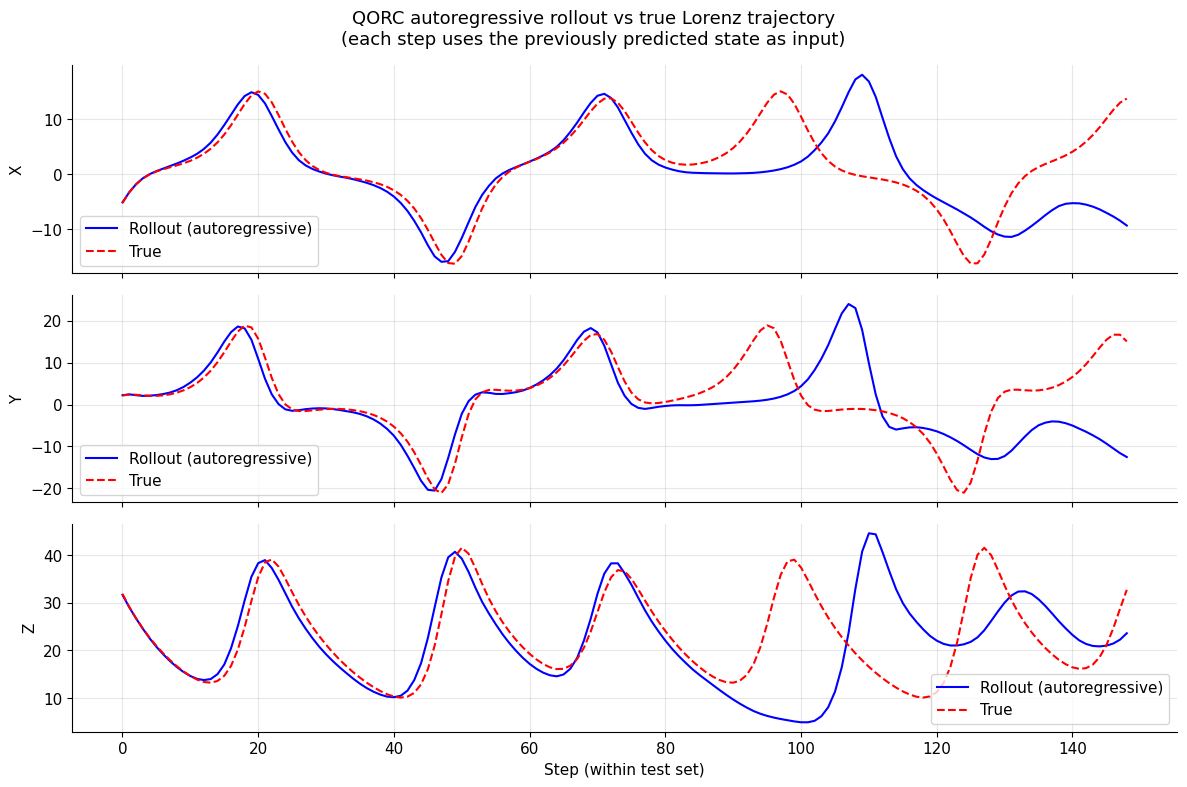

In [58]:
# --- Plot rollout vs true trajectory ---
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for i, coord in enumerate(coords):
    ax = axes[i]
    ax.plot(rollout_pred[:, i], label='Rollout (autoregressive)', color='blue')
    ax.plot(rollout_true[:, i], label='True', color='red', linestyle='--')
    ax.set_ylabel(coord.upper())
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Step (within test set)')
fig.suptitle(
    'QORC autoregressive rollout vs true Lorenz trajectory\n'
    '(each step uses the previously predicted state as input)',
    fontsize=13,
)
plt.tight_layout()
plt.show()


## Next directions

This notebook provides a self-contained QORC baseline for one-step-ahead Lorenz forecasting. Here are natural extensions to explore:

**Hyperparameter exploration:**
- `n_photons`: Try 2, 3, 4 — more photons increase the output dimension and simulation cost.
- `n_layer`: Add deeper quantum circuits (2–3 layers) for richer feature maps.
- `hidden_dim`: Adjust MLP hidden dimension (32, 64, 128).
- `lr`: Try different learning rates (5 × 10⁻⁴, 1 × 10⁻³, 5 × 10⁻³).
- `batch_size`: Test with 16, 32, 64.

**Quantum circuit variants:**
- Use trainable (vs fixed) interferometer layers (full end-to-end training).
- Vary the quantum measurement strategy (`PROBABILITIES`, `SAMPLE_COUNT`, etc.).
- Test different photon bunching regimes.

**Comparison experiments:**
- **Baseline**: classical MLP on raw `(x, y, z)` features only (no reservoir).
- **Classical reservoir**: random Gaussian feature map of the same output dimension.
- **Quantum vs classical reservoir**: direct performance comparison to isolate the contribution of the quantum feature map.

**Multi-step forecasting:**
- Train for $k$-step-ahead prediction using `TimeSeriesDataset`.
- Compare how one-step vs multi-step training affect long-horizon generalisation.

**Robustness analysis:**
- Rollout evaluation: feed predictions back as inputs and measure error accumulation.
- Sensitivity to random circuit seeds.
- Error propagation over many steps on the chaotic attractor.

**Other time series**:
- A paper from 2025: [Quantum vs. classical: A comprehensive benchmark study for predicting time series with variational quantum machine learning](https://iopscience.iop.org/article/10.1088/2632-2153/ae365f) (published in Machine Learning: Science and Technology, Volume 7, Number 1) use other datasets for benchmarking purposes and they can be found on their [GitHub repo](https://github.com/tobias-fllnr/VariationalQMLTimeSeriesBenchmark/tree/main/TimeseriesData). A next step could be to compare the performance with other datasets (of order 1).


## Appendix: Implementation summary

**Task:** One-step-ahead forecasting of the Lorenz system (`x`, `y`, `z` coordinates jointly).

**Pipeline recap:**

| Step | Description |
|---|---|
| Data split | 70 % train / 15 % val / 15 % test (sequential, no shuffle) |
| Normalisation | Z-score with train statistics; applied to all splits |
| Reservoir | Fixed random quantum optical circuit (Perceval + Merlin) |
| Feature extraction | Run reservoir once; store outputs as tensors |
| Readout training | MLP: `Linear(hidden=64) → ReLU → Linear(3)` |
| Optimiser | Adam, lr = 1 × 10⁻³, 200 epochs, batch size 32 |
| Evaluation | MSE and MAE on denormalised predictions |

**Key design choices:**
1. Quantum features are extracted via `batch_compute_quantum_layer` to avoid memory overflow.
2. MLP input = `[quantum_features ⊕ original_input]` (concatenated along the feature axis).
3. Training uses a shuffled `DataLoader`; validation is evaluated on the full split at each epoch.
4. Denormalisation uses the *training* mean and std to avoid data leakage in the reported metrics.
